In [26]:
import pandas as pd

df = pd.read_csv("../data/data.csv")

df.head()

df.isnull().sum()
df["Churn"].value_counts()
df['TotalCharges'].dtype

<StringDtype(na_value=nan)>

In [27]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].dtype
df["TotalCharges"].isnull().sum()
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

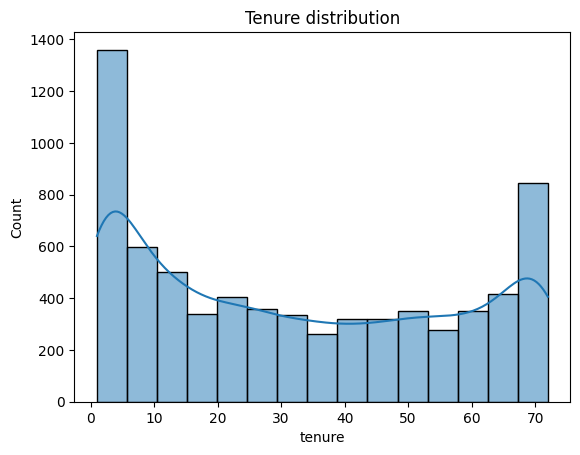

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['tenure'],kde=True)
plt.title("Tenure distribution")
plt.show()

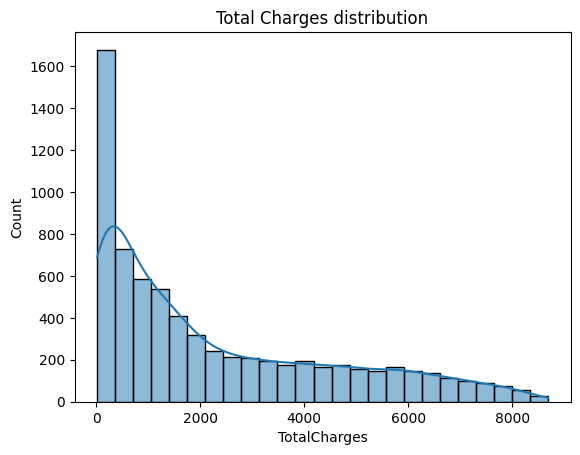

In [29]:
sns.histplot(df['TotalCharges'],kde=True)
plt.title("Total Charges distribution")
plt.show()

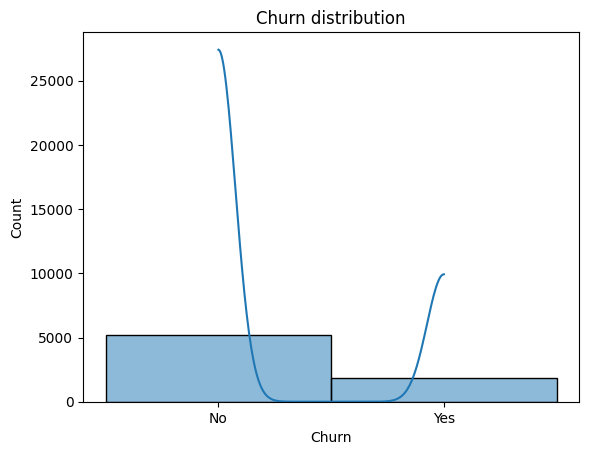

In [30]:
sns.histplot(df['Churn'],kde=True)
plt.title("Churn distribution")
plt.show()

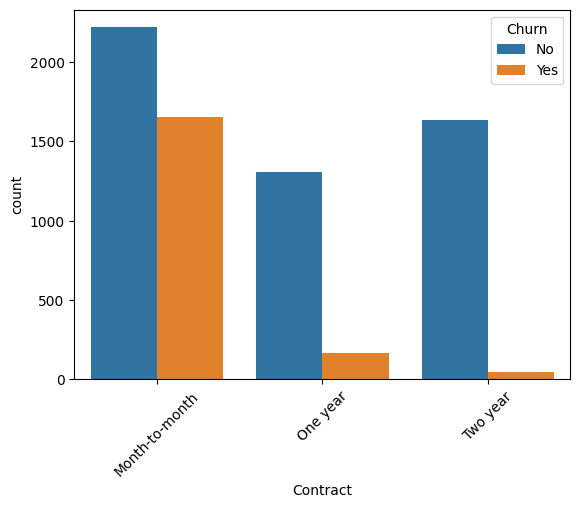

In [31]:
sns.countplot(x='Contract',hue='Churn',data=df)
plt.xticks(rotation=45)
plt.show()

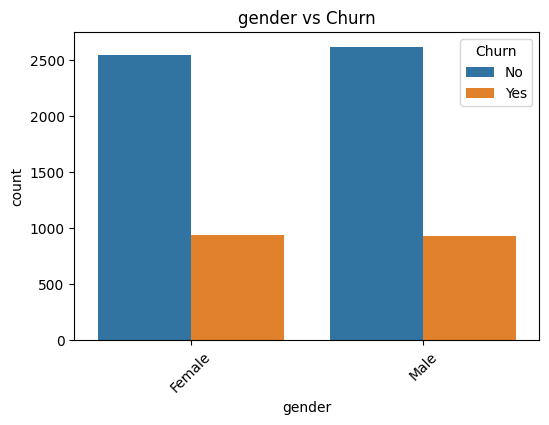

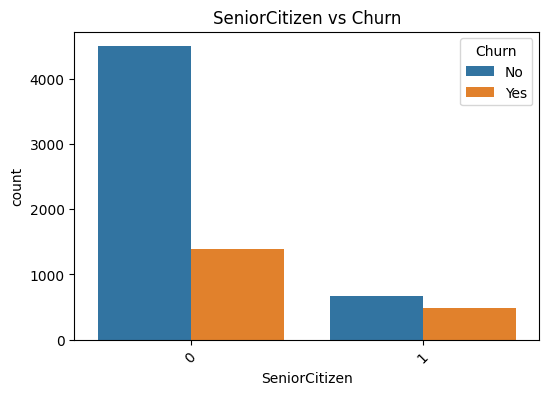

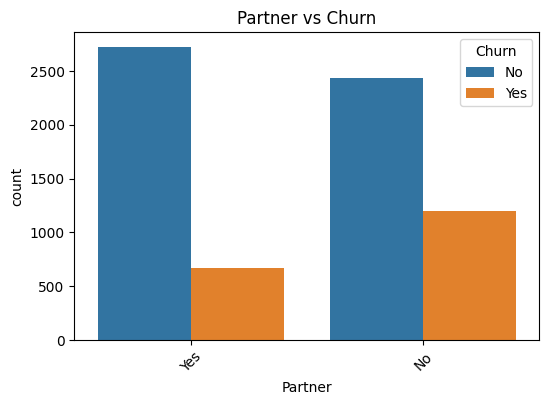

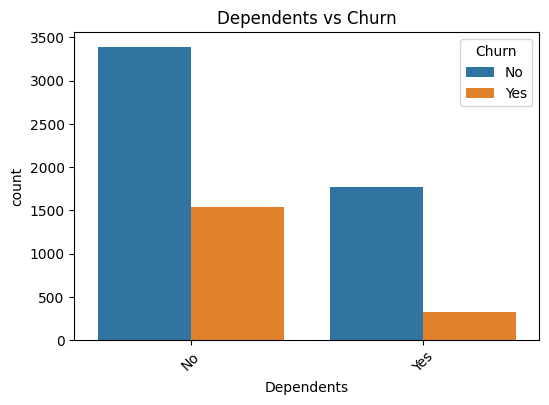

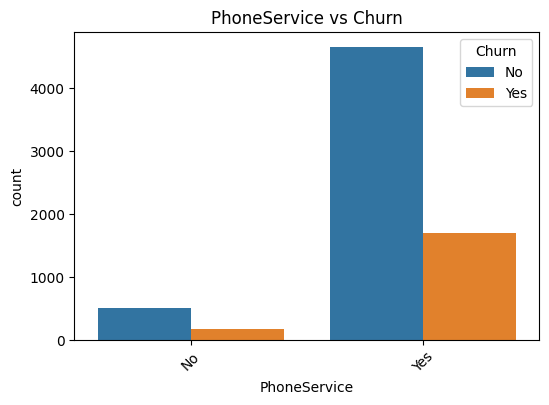

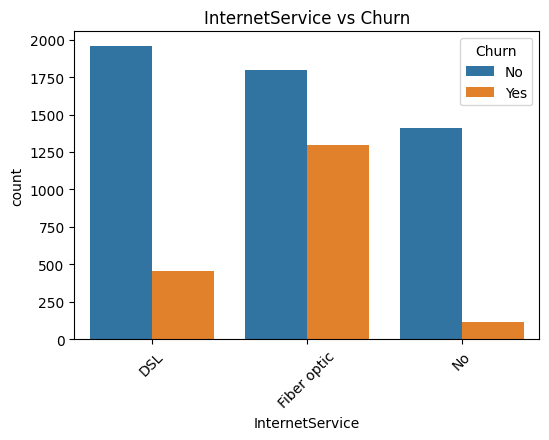

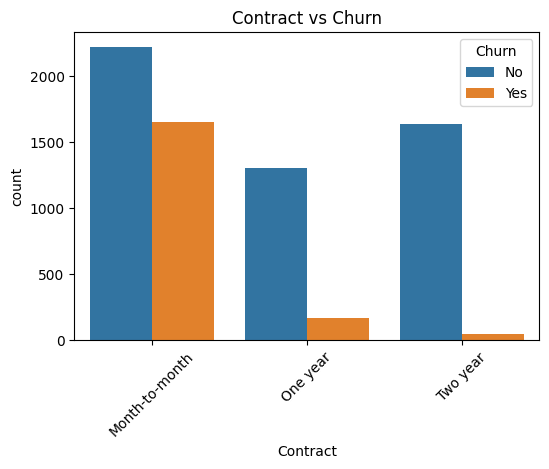

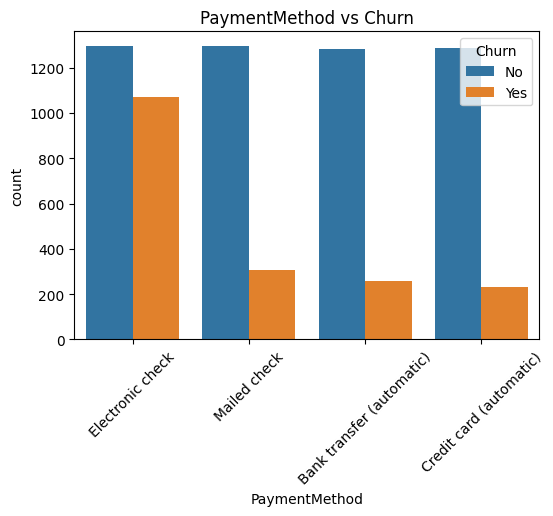

In [32]:
categorical_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',   
    'PhoneService',
    'InternetService',
    'Contract',
    'PaymentMethod'
]
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Churn')
    plt.show()

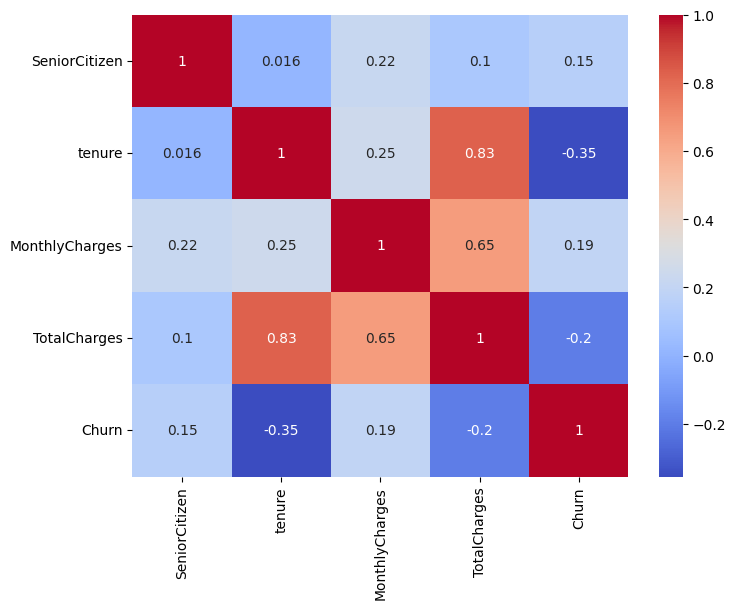

In [33]:
# correlation analysis
import numpy as np
# convert target to binary
df['Churn'] = df['Churn'].map({'Yes' : 1, 'No' : 0})
# select numeric cols
numeric_df = df.select_dtypes(include=np.number)
# compute correlation matrix
corr = numeric_df.corr()

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

# Key Insights

1. Dataset is imbalanced.
2. Month-to-month contracts show higher churn.
3. Customers with higher monthly charges churn more.
4. Customers with longer tenure churn less.
5. Fiber optic internet users show higher churn.

STEP-3 : DATA CLEANING + PREPROCESSING PIPELINE

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/data.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# feature engineering
x = df.drop('Churn', axis=1)
y = df['Churn']
y = y.map({'Yes': 1, 'No': 0})
x=x.drop('customerID', axis=1)


# print(x.shape)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y ensures that the class distribution in the train and test sets is similar to the original dataset.
categorical_cols = x.select_dtypes(include='object').columns
numeric_cols = x.select_dtypes(include=np.number).columns
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')
Numeric columns: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


C:\Users\Krisha patel\AppData\Local\Temp\ipykernel_22004\1702775603.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(include='object').columns


In [35]:
# build preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# numeric features: scale them using StandardScaler
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# categorical features: 
cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numeric_cols),
        ('cat', cat_pipeline, categorical_cols)
    ]
)


# why not label encoding: DSL:0,fiber:1,No:2
# model may think 2>1>0 which is not the case
# one hot coding creates separate binary cols for each category, avoiding this issue
# in this case DSL: 1 0 0, 
#            fiber: 0 1 0, 
#               No: 0 0 1


x_train_processed = preprocessor.fit_transform(x_train) #avoid data leakage
x_test_processed = preprocessor.transform(x_test) #use the same preprocessor to transform test data
print("Processed training data shape:", x_train_processed.shape)
print("Processed test data shape:", x_test_processed.shape)

Processed training data shape: (5634, 45)
Processed test data shape: (1409, 45)


Raw Data
   ↓
Train-Test Split
   ↓
Scaling + Encoding
   ↓
Processed Features
   ↓
Model Training

STEP-4 : BASELINE MODEL BUILDING

         Logistic Regression
         Decision Tree
         Random Forest

Accuracy :  0.8055358410220014
Precision :  0.6572327044025157
Recall :  0.5588235294117647
F1 Score :  0.6040462427745664
Confusion Matrix:
 [[926 109]
 [165 209]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



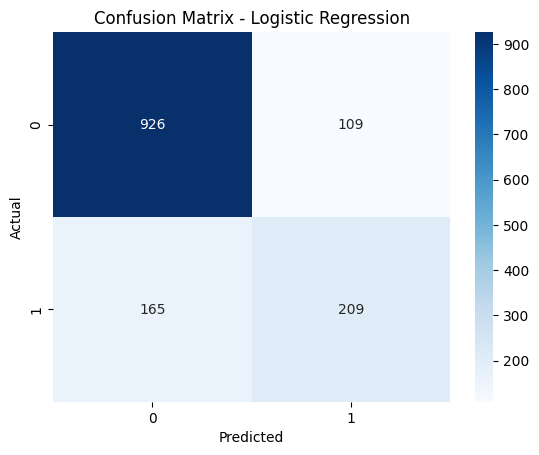

In [36]:
# Logistic regression
# import models and metrics 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,classification_report,confusion_matrix

# train model
lr_model = LogisticRegression()
lr_model.fit(x_train_processed,y_train)
# predictions
y_pred_lr = lr_model.predict(x_test_processed)
# evaluate
print("Accuracy : ",accuracy_score(y_test,y_pred_lr))
print("Precision : ",precision_score(y_test,y_pred_lr)) # pos_label=yes beacause target is binary with values 'Yes' and 'No', we want to calculate precision for the 'Yes' class (churned customers)
print("Recall : ",recall_score(y_test,y_pred_lr))
print("F1 Score : ",f1_score(y_test,y_pred_lr,))

cm = confusion_matrix(y_test,y_pred_lr)
print("Confusion Matrix:\n", cm)

print("Classification Report:\n", classification_report(y_test,y_pred_lr))

# visualize confusion matrix
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

In [37]:
# Train Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train_processed,y_train)

# predictions
y_pred_dt = dt_model.predict(x_test_processed)

print("Accuracy : ",accuracy_score(y_test,y_pred_dt))
print("Precision : ",precision_score(y_test,y_pred_dt,)) # pos_label=yes beacause target is binary with values 'Yes' and 'No', we want to calculate precision for the 'Yes' class (churned customers)
print("Recall : ",recall_score(y_test,y_pred_dt,))
print("F1 Score : ",f1_score(y_test,y_pred_dt,))

Accuracy :  0.7288857345635202
Precision :  0.4896373056994819
Recall :  0.5053475935828877
F1 Score :  0.49736842105263157


In [38]:
# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(x_train_processed,y_train)

# predictions
y_pred_rf = rf_model.predict(x_test_processed)
print("Accuracy : ",accuracy_score(y_test,y_pred_rf))
print("Precision : ",precision_score(y_test,y_pred_rf)) # pos_label=yes beacause target is binary with values 'Yes' and 'No', we want to calculate precision for the 'Yes' class (churned customers)
print("Recall : ",recall_score(y_test,y_pred_rf))       
print("F1 Score : ",f1_score(y_test,y_pred_rf))

Accuracy :  0.7778566359119943
Precision :  0.6033898305084746
Recall :  0.47593582887700536
F1 Score :  0.5321375186846039


In [39]:
# create comparision table

results = pd.DataFrame({
    'Model' : ['Logistic Regression', 'Decision Tree', 'Random Forest'],


    'Accuracy' : [accuracy_score(y_test,y_pred_lr),
                  accuracy_score(y_test,y_pred_dt), 
                  accuracy_score(y_test,y_pred_rf)],


    'Precision' : [precision_score(y_test,y_pred_lr),
                   precision_score(y_test,y_pred_dt), 
                   precision_score(y_test,y_pred_rf)],


    'Recall' : [recall_score(y_test,y_pred_lr),
                recall_score(y_test,y_pred_dt),
                recall_score(y_test,y_pred_rf)],

                
    'F1 Score' : [f1_score(y_test,y_pred_lr),
                  f1_score(y_test,y_pred_dt),
                  f1_score(y_test,y_pred_rf)]
})
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.805536   0.657233  0.558824  0.604046
1        Decision Tree  0.728886   0.489637  0.505348  0.497368
2        Random Forest  0.777857   0.603390  0.475936  0.532138


# Baseline Model Insights

1. Logistic Regression provides interpretable baseline performance.
2. Decision Tree captures nonlinear patterns but may overfit.
3. Random Forest improves generalization using ensemble learning.
4. Recall is especially important because missing churners is costly.
5. Accuracy alone is insufficient for imbalanced datasets.

STEP-5 : HANDLING IMBALANCED DATA

In [40]:
y.value_counts()
y.value_counts(normalize=True)*100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Split Data
   ↓
Apply SMOTE ONLY on training set
   ↓
Train Model
   ↓
Evaluate on untouched test set

Why ONLY Training Data?

Because applying SMOTE before split causes:

data leakage

Synthetic samples may leak information into test data.

In [41]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_smote,y_train_smote = smote.fit_resample(x_train_processed,y_train)

# check new distribution
# y_train.value_counts()
# y_train_smote.value_counts()

# retrain models on balanced data
lr_smote = LogisticRegression()

lr_smote.fit(x_train_smote,y_train_smote)

y_pred_lr_smote = lr_smote.predict(x_test_processed)

print("Logistic Regression with SMOTE: \n")
print("Accuracy : ",accuracy_score(y_test,y_pred_lr_smote))
print("Precision : ",precision_score(y_test,y_pred_lr_smote))
print("Recall : ",recall_score(y_test,y_pred_lr_smote,))
print("F1 Score : ",f1_score(y_test,y_pred_lr_smote))

print()
# retrain random forest on balanced data
rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(x_train_smote,y_train_smote)
y_pred_rf_smote = rf_smote.predict(x_test_processed)

print("Random Forest with SMOTE: \n")
print("Accuracy : ",accuracy_score(y_test,y_pred_rf_smote)) 
print("Precision : ",precision_score(y_test,y_pred_rf_smote))
print("Recall : ",recall_score(y_test,y_pred_rf_smote,))
print("F1 Score : ",f1_score(y_test,y_pred_rf_smote))

print()

# retrain decision tree on balanced data
dt_smote = DecisionTreeClassifier(random_state=42)  
dt_smote.fit(x_train_smote,y_train_smote)
y_pred_dt_smote = dt_smote.predict(x_test_processed)

print("Decision Tree with SMOTE: \n")
print("Accuracy : ",accuracy_score(y_test,y_pred_dt_smote))
print("Precision : ",precision_score(y_test,y_pred_dt_smote))
print("Recall : ",recall_score(y_test,y_pred_dt_smote))
print("F1 Score : ",f1_score(y_test,y_pred_dt_smote))

Logistic Regression with SMOTE: 

Accuracy :  0.7374024130589071
Precision :  0.5033898305084745
Recall :  0.7941176470588235
F1 Score :  0.6161825726141079

Random Forest with SMOTE: 

Accuracy :  0.7757274662881476
Precision :  0.5805555555555556
Recall :  0.5588235294117647
F1 Score :  0.5694822888283378

Decision Tree with SMOTE: 

Accuracy :  0.7310149041873669
Precision :  0.4939467312348668
Recall :  0.5454545454545454
F1 Score :  0.5184243964421855


In [42]:
# compare results before and after SMOTE
smote_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Logistic Regression + SMOTE',
        'Random Forest',
        'Random Forest + SMOTE'
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr_smote),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_smote)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr_smote),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_smote)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr_smote),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_smote)
    ]
})

print(smote_results)

                         Model    Recall  Precision  F1 Score
0          Logistic Regression  0.558824   0.657233  0.604046
1  Logistic Regression + SMOTE  0.794118   0.503390  0.616183
2                Random Forest  0.475936   0.603390  0.532138
3        Random Forest + SMOTE  0.558824   0.580556  0.569482


# Imbalance Handling Insights

1. Accuracy alone is misleading for churn prediction.
2. SMOTE improved minority-class detection.
3. Recall increased after balancing the dataset.
4. Higher recall helps identify more at-risk customers.
5. Precision-recall tradeoff must be considered from a business perspective.

STEP-6 : HYPERPARAMETER TUNING
SET BEFORE TRANING
1. What hyperparameters are
2. Overfitting vs underfitting
3. Cross-validation
4. GridSearchCV
5. RandomizedSearchCV
6. Tuning Random Forest
7. Performance comparison
8. Best model selection

In [43]:
# import tuning tools
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# random forest hyperparameter tuning
# Because:

# strong baseline
# widely used
# easy to tune
# handles nonlinear patterns well
param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [5, 10, 20, None],
    'min_samples_split' : [2, 5, 10], # internal nodes should have at least 2,5,10 samples to prevent overfitting
    'min_samples_leaf' : [1, 2, 4] # leaf nodes should have at least 1,2,4 samples to prevent overfitting
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1', # optimize for F1 score to balance precision and recall
    n_jobs=-1, # use all CPU cores for faster training
    verbose=1 # show progress
)

grid_search.fit(x_train_smote,y_train_smote)
print(grid_search.best_params_)
print(grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(x_test_processed)

print("Tuned Random Forest: \n")
print("Accuracy : ",accuracy_score(y_test,y_pred_best_rf))
print("Precision : ",precision_score(y_test,y_pred_best_rf))
print("Recall : ",recall_score(y_test,y_pred_best_rf))
print("F1 Score : ",f1_score(y_test,y_pred_best_rf))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.8497685649651368
Tuned Random Forest: 

Accuracy :  0.7743080198722498
Precision :  0.5777777777777777
Recall :  0.5561497326203209
F1 Score :  0.5667574931880109


In [44]:
comparison = pd.DataFrame({
    'model' : ['Random Forest',
               'Random Forest + SMOTE',
               'Tuned Random Forest'],

    'F1 Score' : [f1_score(y_test,y_pred_rf),
                  f1_score(y_test,y_pred_rf_smote),
                  f1_score(y_test,y_pred_best_rf)],

    'Recall' : [recall_score(y_test,y_pred_rf),
                recall_score(y_test,y_pred_rf_smote),
                recall_score(y_test,y_pred_best_rf)]
})
print(comparison)

                   model  F1 Score    Recall
0          Random Forest  0.532138  0.475936
1  Random Forest + SMOTE  0.569482  0.558824
2    Tuned Random Forest  0.566757  0.556150


In [45]:
# randomized search 
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10, # number of random combinations to try
    cv=5,
    scoring='f1', # optimize for F1 score to balance precision and recall
    n_jobs=-1, # use all CPU cores for faster training
    random_state=42, # for reproducibility
)
random_search.fit(x_train_smote,y_train_smote)
print(random_search.best_params_)
print(random_search.best_score_)

best_rf_random = random_search.best_estimator_  
y_pred_best_rf_random = best_rf_random.predict(x_test_processed)

print("Accuracy : ",accuracy_score(y_test,y_pred_best_rf_random))
print("Randomized Search Tuned Random Forest: \n")
print("Recall : ",recall_score(y_test,y_pred_best_rf_random))
print("F1 Score : ",f1_score(y_test,y_pred_best_rf_random))



{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
0.8497685649651368
Accuracy :  0.7743080198722498
Randomized Search Tuned Random Forest: 

Recall :  0.5561497326203209
F1 Score :  0.5667574931880109


In [46]:
# compare grid search and randomized search results
tuning_comparison = pd.DataFrame({
    'Model' : ['Random Forest', 'Random Forest + SMOTE', 'Grid Search Tuned RF', 'Randomized Search Tuned RF'],
    'F1 Score' : [f1_score(y_test,y_pred_rf),
                  f1_score(y_test,y_pred_rf_smote),
                  f1_score(y_test,y_pred_best_rf),
                  f1_score(y_test,y_pred_best_rf_random)],
    'Recall' : [recall_score(y_test,y_pred_rf),
                recall_score(y_test,y_pred_rf_smote),
                recall_score(y_test,y_pred_best_rf),
                recall_score(y_test,y_pred_best_rf_random)]
})
print(tuning_comparison)

                        Model  F1 Score    Recall
0               Random Forest  0.532138  0.475936
1       Random Forest + SMOTE  0.569482  0.558824
2        Grid Search Tuned RF  0.566757  0.556150
3  Randomized Search Tuned RF  0.566757  0.556150


# Hyperparameter Tuning Insights

1. Default hyperparameters are rarely optimal.
2. Cross-validation improves evaluation reliability.
3. GridSearchCV systematically explores parameter combinations.
4. RandomizedSearchCV offers faster optimization.
5. Tuned Random Forest improved overall classification performance.

TUNE LOGISTIC REGRESSION

In [47]:
param_grid_lr = {
    'C' : [0.01,0.1,1,10,100], # smaller C means stronger regularization, larger C means weaker regularization
    'penalty' : ['l1','l2'], # l1 for feature selection, l2 for regularization
    'solver' : ['liblinear'] # liblinear supports optimization of both l1 and l2 penalties
}
grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1 # show progress
)

grid_search_lr.fit(x_train_smote,y_train_smote)
print(grid_search_lr.best_params_)
print(grid_search_lr.best_score_)
best_lr = grid_search_lr.best_estimator_
y_pred_best_lr = best_lr.predict(x_test_processed)

print("Tuned Logistic Regression: \n")
print("Accuracy : ",accuracy_score(y_test,y_pred_best_lr))
print("Recall : ",recall_score(y_test,y_pred_best_lr))
print("F1 Score : ",f1_score(y_test,y_pred_best_lr))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
0.7843398123660122
Tuned Logistic Regression: 

Accuracy :  0.7388218594748048
Recall :  0.7941176470588235
F1 Score :  0.6174636174636174


c:\Users\Krisha patel\Desktop\customer-churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [48]:
# compare grid search and randomized search results
tuning_comparison = pd.DataFrame({ 
    'Model' : [
               'Grid Search Tuned RF',
               'Grid Search Tuned LR'],

    'F1 Score' : [
                  f1_score(y_test,y_pred_best_rf),
                  f1_score(y_test,y_pred_best_lr)],

    'Recall' : [
                recall_score(y_test,y_pred_best_rf),
                recall_score(y_test,y_pred_best_lr)],
    'interpretability' : [ # interpretability is important for understanding why the model is making certain predictions, which can be crucial for gaining trust and insights from the model's decisions.
        'Low',
        'High'
    ],
    'complexity' : [ #
        'High',
        'Low'
    ]
})   
print(tuning_comparison)

                  Model  F1 Score    Recall interpretability complexity
0  Grid Search Tuned RF  0.566757  0.556150              Low       High
1  Grid Search Tuned LR  0.617464  0.794118             High        Low


STEP-7 : ADVANCED MODEL : XGBoost

Used heavily in:

Kaggle competitions,
fintech,
customer analytics,
risk modeling,
recommendation systems

In [49]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss' #Log loss measures probability prediction quality.
) 

# train
xgb_model.fit(x_train_smote,y_train_smote)
y_pred_xgb = xgb_model.predict(x_test_processed)

print("XGBoost: \n")
print("Accuracy : ",accuracy_score(y_test,y_pred_xgb))  
print("Precision : ",precision_score(y_test,y_pred_xgb))
print("Recall : ",recall_score(y_test,y_pred_xgb))
print("F1 Score : ",f1_score(y_test,y_pred_xgb))

XGBoost: 

Accuracy :  0.7778566359119943
Precision :  0.5792207792207792
Recall :  0.5962566844919787
F1 Score :  0.5876152832674572


In [50]:
param_grid_xgb = {
    'n_estimators' : [100,200], # number of trees in the ensemble, more trees can improve performance but also increase training time and risk of overfitting
    'learning_rate' : [0.01,0.1,0.2], # small rate=slower but safer learning,large rate=faster but overfitting risk
    'max_depth' : [3,5,7],
    'subsample' : [0.8,1.0], # subsample is the fraction of training samples used for growing each tree, lower values can prevent overfitting but too low may lead to underfitting
    'colsample_bytree' : [0.8,1.0] # colsample_bytree is the fraction of features used for growing each tree, lower values can prevent overfitting but too low may lead to underfitting
}

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42,eval_metric='logloss'),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search_xgb.fit(x_train_smote,y_train_smote)
print(grid_search_xgb.best_params_)
print(grid_search_xgb.best_score_)
best_xgb = grid_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(x_test_processed)

print("Tuned XGBoost: \n")
print("Accuracy : ",accuracy_score(y_test,y_pred_best_xgb))
print("Recall : ",recall_score(y_test,y_pred_best_xgb))
print("Precision : ",precision_score(y_test,y_pred_best_xgb))
print("F1 Score : ",f1_score(y_test,y_pred_best_xgb))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
0.8385552227825086
Tuned XGBoost: 

Accuracy :  0.7750177430801988
Recall :  0.6229946524064172
Precision :  0.5696821515892421
F1 Score :  0.5951468710089399


In [51]:
# import joblib

# # Save the trained model
# joblib.dump(best_xgb, 'app/model.pkl')

# # save scaler
# joblib.dump(scaler, 'app/scaler.pkl')

# # save feature columns
# joblib.dump(all_feature_names, 'app/feature_names.pkl')

# print("Model, scaler, and feature names saved successfully!")

In [52]:
# compare all models
final_comparison = pd.DataFrame({
    'Model' : ['Tuned Random Forest',
               'Tuned Logistic Regression',
               'Tuned XGBoost'],
    
    
    'F1 Score' : [f1_score(y_test,y_pred_best_rf),
                    f1_score(y_test,y_pred_best_lr),
                    f1_score(y_test,y_pred_best_xgb)],

    'Recall' : [recall_score(y_test,y_pred_best_rf),
                recall_score(y_test,y_pred_best_lr),
                recall_score(y_test,y_pred_best_xgb)],

    'Precision' : [precision_score(y_test,y_pred_best_rf),
                    precision_score(y_test,y_pred_best_lr),
                    precision_score(y_test,y_pred_best_xgb)],
})
print(final_comparison)

                       Model  F1 Score    Recall  Precision
0        Tuned Random Forest  0.566757  0.556150   0.577778
1  Tuned Logistic Regression  0.617464  0.794118   0.505102
2              Tuned XGBoost  0.595147  0.622995   0.569682


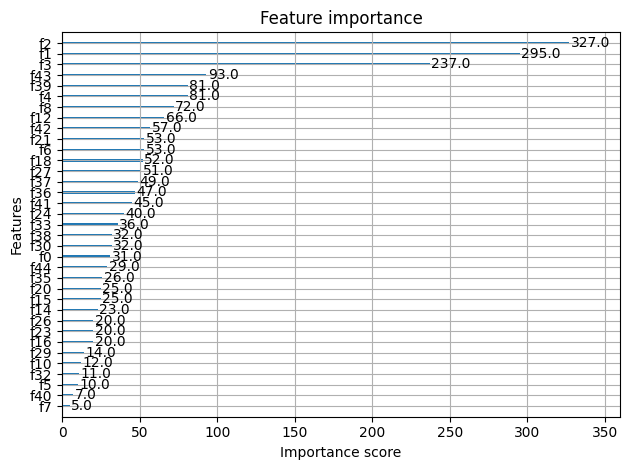

In [53]:
import matplotlib.pyplot as plt
from xgboost import plot_importance
plot_importance(best_xgb)
# prevent overlapping labels
plt.tight_layout()

plt.show()
# this plot shows feature f2 ,in this case tenure and total charges are the most important features for predicting churn, which makes sense because customers with shorter tenure and higher total charges are more likely to churn.


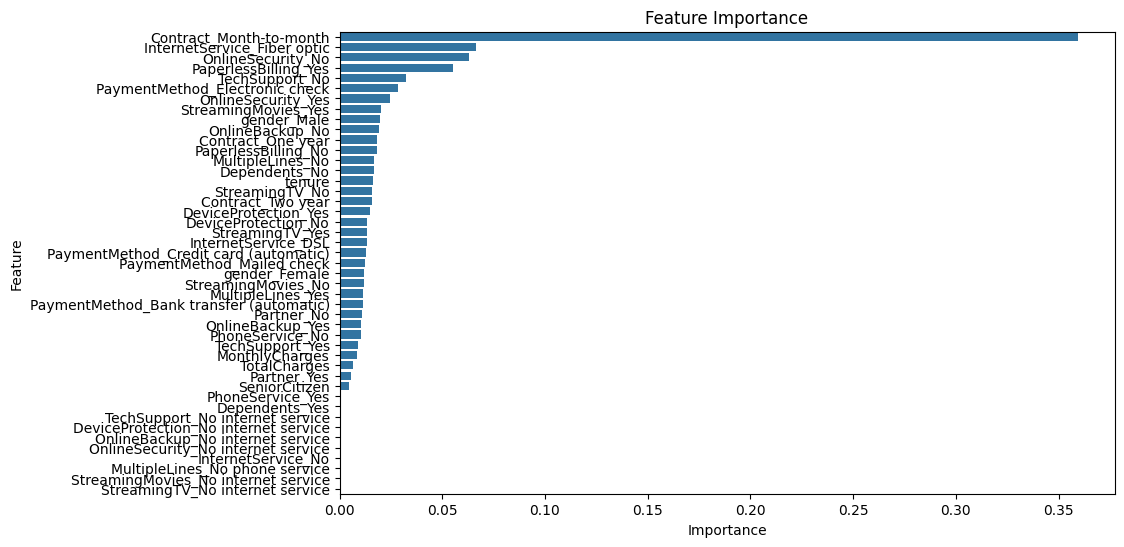

In [54]:
encoded_feature_names = preprocessor.named_transformers_['cat']\
    .get_feature_names_out(categorical_cols)

all_feature_names = np.concatenate([
    numeric_cols,
    encoded_feature_names
])

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)
# print(importance_df.head(10))
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=importance_df.head(45))
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [55]:
# conclusion
# contract_month-to-month has the highest importance, which means customers with month-to-month contracts are more likely to churn compared to those with one-year or two-year contracts. 
# This makes sense because customers with longer-term contracts may have more incentives to stay, such as discounts or penalties for early termination.


# XGBoost Insights

1. XGBoost uses boosting to sequentially improve weak learners.
2. It captures complex nonlinear relationships effectively.
3. Feature importance analysis reveals major churn drivers.
4. Ensemble methods improved predictive capability.
5. Model selection should balance performance and interpretability.

STEP-8 : MODEL EXPLAINABILITY + BUSINESS INSIGHTS

In [56]:
# SHAP : contribution of each feature for prediction
# shap explain : which features pushed prediction UP
#                which features pushed prediction down


c:\Users\Krisha patel\Desktop\customer-churn-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


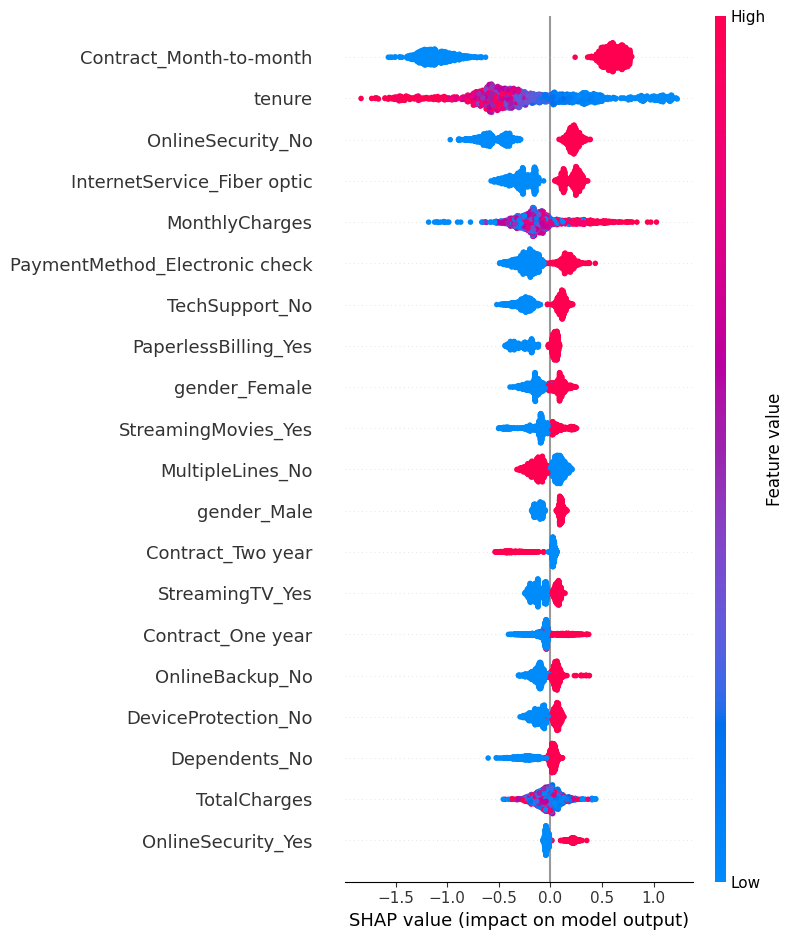

In [57]:
# import shap
import shap
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(x_test_processed) #this computes feture contributions
shap.summary_plot(shap_values,
                  x_test_processed,
                  feature_names=all_feature_names
)
plt.show()

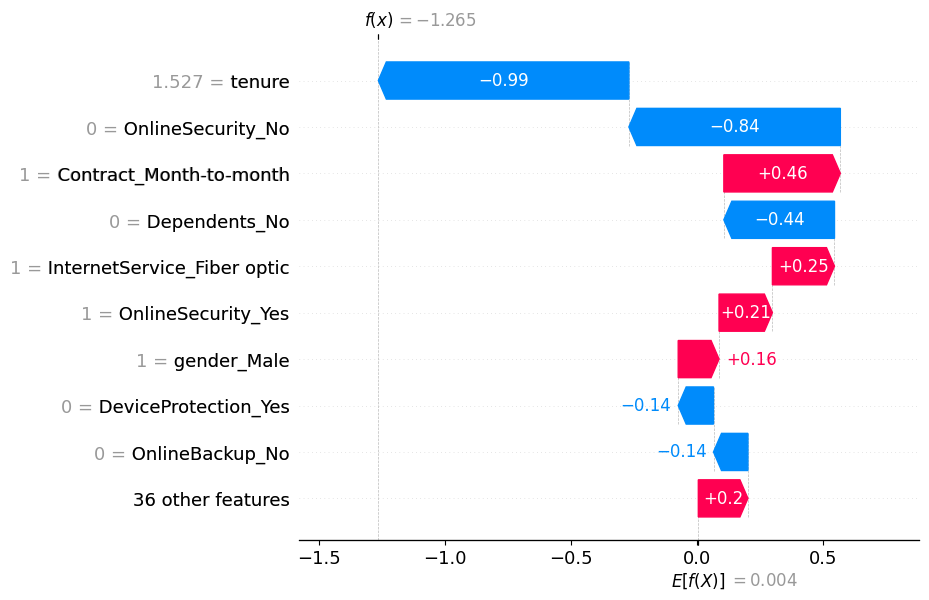

In [58]:
sample_index=10
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=x_test_processed[sample_index],
        feature_names=all_feature_names
    )
)

# Final Business Conclusions

1. Contract type, tenure, and monthly charges were major churn drivers.
2. Customers on month-to-month contracts showed significantly higher churn probability.
3. Long-term customers demonstrated stronger retention behavior.
4. SHAP analysis improved model interpretability by explaining individual predictions.
5. The project demonstrates how machine learning can support customer retention strategies.

In [59]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [60]:
from src.save_model import save_model_artifacts

feature_names = preprocessor.get_feature_names_out()

save_model_artifacts(
    best_xgb,
    preprocessor,
    feature_names
)

Model artifacts saved successfully!


In [61]:
x.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='str')